Import libraries for geospatial data analysis and plotting.
Also explicitly import pyplot for nuanced matplotlib features.

In [1]:
import geopandas as gpd
import geoplot as gplt
import geoplot.crs as gcrs
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

Read in various geodata files and shapefiles; make sure their CRS are aligned.

In [2]:
county_shape = gpd.read_file('data/Ky_County_Polygons/Ky_County_Polygons_WM.shp')
print(county_shape.crs)
county_shape.to_crs(epsg='4326', inplace=True)
jefferson_co = county_shape[county_shape['NAME']=='JEFFERSON']
print(jefferson_co.crs)

EPSG:3857
EPSG:4326


Exploratory: Read in various geospatial data files to compare and investigate

In [3]:
# read major roads file
major_roads = gpd.read_file('data/Louisville_Metro_Area_KY_Major_Roads.geojson')
major_roads.dropna(inplace=True)    # one row had mostly NaN values
# clip major roads to Jefferson County only
jeffco_roads = gpd.clip(major_roads, jefferson_co)

In [4]:
# read high injury network data file
hi_injury = gpd.read_file('data/Louisville_Metro_KY_-_High_Injury_Network.geojson')

In [5]:
# read bikeways data
bikeways = gpd.read_file('data/Jefferson_County_KY_Bikeways.geojson')

In [6]:
# read TARC bus stop data
bus_stops = gpd.read_file('data/Louisville_Metro_Area_KY__TARC_Bus_Stops.geojson')
bus_stops = gpd.clip(bus_stops, jefferson_co)

In [7]:
# read road context classification
road_details = gpd.read_file('data/Louisville_Metro_KY_Road_Context_Classifications.geojson')

In [8]:
# read midblock crossings file
zebras = gpd.read_file('data/Jefferson_County_KY_Midblock_Crossings.geojson')

In [9]:
# read signalized intersections file
signals = gpd.read_file('data/Jefferson_County_KY_Signalized_Intersections.geojson')

In [10]:
# read centerlines data
centerlines = gpd.read_file('data/Jefferson_County_KY_Street_Centerlines.geojson')

Introductory plot, just for funsies

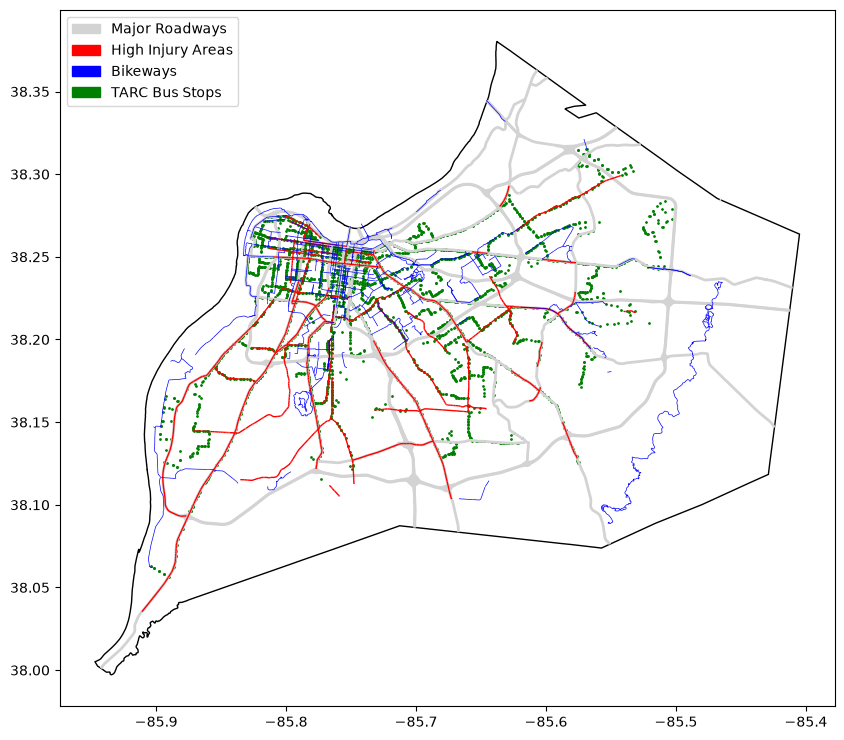

In [ ]:
# Cheat Sheet
# ===========
# geodf.plot(color='color', edgecolor='color')
# or (cmap = 'colormap', column = 'column_name') ... with matplotlib colormaps
# probably want to import matplotlib.pyplot as plt
# multi-layers:
#   fig, ax = plt.subplots(figsize = x, y)
#   geodf1.plot(ax = ax, cmap = 'cmap', etc.)
#   geodf2.plot(ax = ax, etc.)

# read jefferson county spatial data from kygeonet.ky.gov

fig, ax = plt.subplots(figsize = (10, 10))

jefferson_co.plot(ax = ax, color='none', edgecolor='black')
jeffco_roads.plot(ax = ax, color='lightgray', linewidth=2) 
hi_injury.plot(ax = ax, color='red', linewidth=1)
bikeways.plot(ax = ax, color='blue', linewidth=0.5)
bus_stops.plot(ax = ax, color='green', markersize=1)

grey_lines = mpatches.Patch(color='lightgrey', label='Major Roadways')
red_lines = mpatches.Patch(color='red', label='High Injury Areas')
blue_lines = mpatches.Patch(color='blue', label='Bikeways')
green_dots = mpatches.Patch(color='green', label='TARC Bus Stops')

ax.legend(loc='upper left', handles=[grey_lines, red_lines, blue_lines, green_dots], )

plt.show()


Investigate DataFrames

In [12]:
display("bikeways = Designated bike paths and bike lanes in Jefferson County", bikeways.head(3))
display("bus_stops = TARC Bus Stops clipped to within Jefferson County", bus_stops.head(3))
display("hi_injury = High Injury Network of roads based on 2018-2022 crash data", hi_injury.head(3))
display("jeffco_roads = Metro Area Major Roadways clipped to just Jefferson County", jeffco_roads.head(3))
display("signals = Jefferson County Signalized Intersections", major_roads.head(3))
display("road_details = 'Road Context Classifications'", road_details.head(3))
display("zebras = Marked Road Crossings", zebras.head(3))

'bikeways = Designated bike paths and bike lanes in Jefferson County'

,OBJECTID,ROADNAME,MAP_TYPE,MPWBIKEID,SHAPELEN,geometry
0,1,DUMESNIL ST,4,1,186.297444,"LINESTRING (-85.79968 38.2367, -85.79914 38.23..."
1,2,DUMESNIL ST,4,2,388.163770,"LINESTRING (-85.79774 38.23653, -85.7965 38.23..."
2,3,DUMESNIL ST,4,3,56.149861,"LINESTRING (-85.80053 38.23678, -85.80034 38.2..."


'bus_stops = TARC Bus Stops clipped to within Jefferson County'

,OBJECTID,STOPID,STOPABBR,STOPNAME,LON,LAT,geometry
2596,2597,1557,15495,Dixie @ Watson,-85.890400,38.056361,POINT (-85.8904 38.05637)
2865,2866,8762,16486,Watson @ Dixie,-85.891252,38.056591,POINT (-85.89126 38.0566)
2866,2867,8763,16488,Watson @ Kinross,-85.893672,38.057863,POINT (-85.89368 38.05787)


'hi_injury = High Injury Network of roads based on 2018-2022 crash data'

...

,OBJECTID,ROAD_NAME,COUNTY_NAME,HWY_SYMBOL,HWY_NUM,SHAPELEN,geometry
0,1,MAIN ST,TRIMBLE,US HWY,42,2463.895394,"LINESTRING (-85.31895 38.58616, -85.31893 38.5..."
1,2,US HIGHWAY 421,TRIMBLE,US HWY,421,18394.778967,"LINESTRING (-85.27552 38.55849, -85.27554 38.5..."
2,3,MAIN ST,TRIMBLE,US HWY,42,908.342866,"LINESTRING (-85.31759 38.59279, -85.31723 38.5..."


"road_details = 'Road Context Classifications'"

,OBJECTID,RWCOMPKEY,FROM_ADDRESS,ROADNAME,DIR,STRNAME,TYPE,LOCROSSPR,LOCROSSNA,LOCROSSSU,...,HICROSSSU,SPEED,MUNI_NAME,COUNDIST,OWNER_NAME,CORE_CLASS,ROUTE_LBL,CONTEXT_CLASS,SHAPELEN,geometry
0,1,40382,5035,TERRY RD,,TERRY,RD,,LA VEL,LN,...,DR,45,LOUISVILLE,1,STATE,MINOR ARTERIAL,KY-1727,C2R,558.313444,"LINESTRING (-85.86439 38.17455, -85.86454 38.1..."
1,2,21655,500,S 6TH ST,S,6TH,ST,W,MUHAMMAD ALI,BLVD,...,ST,25,LOUISVILLE,4,METRO,MINOR ARTERIAL,,C6,804.105028,"LINESTRING (-85.76081 38.2515, -85.76082 38.25..."
2,3,17924,307,E BURNETT AVE,E,BURNETT,AVE,,MARIE,ST,...,ST,25,LOUISVILLE,6,METRO,PRIMARY COLLECTOR,,C5,498.711366,"LINESTRING (-85.75256 38.22634, -85.75166 38.2..."


'zebras = Marked Road Crossings'

,OBJECTID,ROADNAME,CID,CROSSTYPE,CROSSST,ATTRACT,ATTRACTADD,STATUS,MILEPOINT,AIDTYPE,...,ONE_WAY,MUNI_NAME,MAIN_DIST,OWNER_ABRV,MAIN_RESP,CLASS_ABRV,ROUTE_LBL,POINT_X,POINT_Y,geometry
0,1,DUNCAN ST,96,SCHOOL,MID-BLOCK,ATKINSON ELEMENTARY,2811 DUNCAN ST,EXISTING,NaN,SPEED HUMPS,...,N,LOUISVILLE,WEST,METR,METRO,LOCAL,,-85.797839,38.263913,POINT (-85.79784 38.26392)
1,2,DUNCAN ST,97,SCHOOL,N 29TH ST,ATKINSON ELEMENTARY,2811 DUNCAN ST,EXISTING,NaN,SPEED HUMPS,...,N,LOUISVILLE,WEST,METR,METRO,LOCAL,,-85.798602,38.263996,POINT (-85.79861 38.264)
2,3,VERMONT AVE,246,SCHOOL,S 36TH ST,YOUNG ELEMENTARY,3526 W MUHAMMAD ALI BLVD,EXISTING,NaN,SPEED HUMPS,...,N,LOUISVILLE,WEST,METR,METRO,LOCAL,,-85.811211,38.255984,POINT (-85.81122 38.25599)


Because of "midblock" in filename, verify zebras df includes crossings that are also at intersections.

,OBJECTID,ROADNAME,CID,CROSSTYPE,CROSSST,ATTRACT,ATTRACTADD,STATUS,MILEPOINT,AIDTYPE,...,ONE_WAY,MUNI_NAME,MAIN_DIST,OWNER_ABRV,MAIN_RESP,CLASS_ABRV,ROUTE_LBL,POINT_X,POINT_Y,geometry
0,1,DUNCAN ST,96,SCHOOL,MID-BLOCK,ATKINSON ELEMENTARY,2811 DUNCAN ST,EXISTING,NaN,SPEED HUMPS,...,N,LOUISVILLE,WEST,METR,METRO,LOCAL,,-85.797839,38.263913,POINT (-85.79784 38.26392)
1,2,DUNCAN ST,97,SCHOOL,N 29TH ST,ATKINSON ELEMENTARY,2811 DUNCAN ST,EXISTING,NaN,SPEED HUMPS,...,N,LOUISVILLE,WEST,METR,METRO,LOCAL,,-85.798602,38.263996,POINT (-85.79861 38.264)
2,3,VERMONT AVE,246,SCHOOL,S 36TH ST,YOUNG ELEMENTARY,3526 W MUHAMMAD ALI BLVD,EXISTING,NaN,SPEED HUMPS,...,N,LOUISVILLE,WEST,METR,METRO,LOCAL,,-85.811211,38.255984,POINT (-85.81122 38.25599)
3,4,FRANKFORT AVE,107,SCHOOL,RESERVOIR AVE,FIELD ELEMENTARY,120 SACRED HEART LN,EXISTING,2.165,RRFB - SIDE MOUNTED,...,N,LOUISVILLE,EAST,STAT,STATE,MAJART,US-60,-85.680643,38.254485,POINT (-85.68065 38.25449)
4,5,OUTER LOOP,187,SCHOOL,MID-BLOCK,MOORE HIGH SCHOOL,6415 OUTER LOOP,EXISTING,8.741,SCHOOL ZONE WARNING SYSTEM,...,N,LOUISVILLE,WEST,STAT,STATE,MAJART,KY-1065,-85.638144,38.137781,POINT (-85.63815 38.13779)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,347,N 17TH ST,323,PEDESTRIAN,ROWAN ST,NaN,NaN,EXISTING,NaN,NONE,...,,LOUISVILLE,WEST,METR,METRO,LOCAL,,-85.777798,38.260426,POINT (-85.7778 38.26043)
347,348,N 17TH ST,323,PEDESTRIAN,ROWAN ST,NaN,NaN,EXISTING,NaN,NONE,...,,LOUISVILLE,WEST,METR,METRO,LOCAL,,-85.777824,38.260279,POINT (-85.77782 38.26028)
348,349,HALE AVE,324,PEDESTRIAN,S 17TH ST,NaN,NaN,EXISTING,NaN,NONE,...,,LOUISVILLE,WEST,METR,METRO,LOCAL,,-85.783861,38.237958,POINT (-85.78386 38.23796)
349,350,HALE AVE,324,PEDESTRIAN,S 17TH ST,NaN,NaN,EXISTING,NaN,SPEED HUMPS,...,,LOUISVILLE,WEST,METR,METRO,LOCAL,,-85.783715,38.237942,POINT (-85.78371 38.23794)


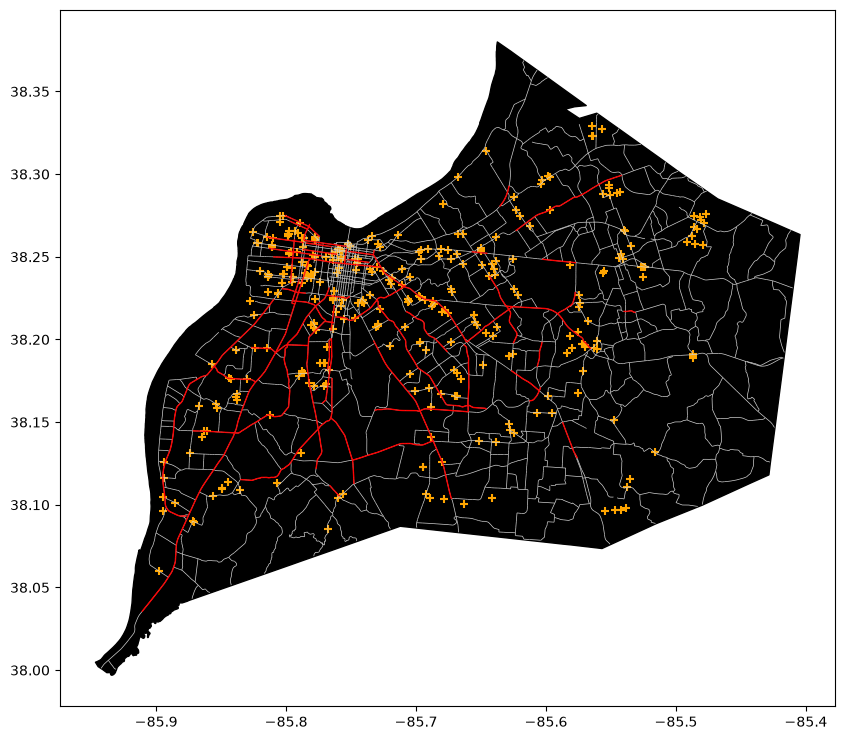

In [13]:
display(zebras)

fig, ax = plt.subplots(figsize = (10, 10))
jefferson_co.plot(ax = ax, color='black', edgecolor='black')
road_details.plot(ax = ax, color='lightgray', linewidth=0.5) 
hi_injury.plot(ax = ax, color='red', linewidth=1)
zebras.plot(ax = ax, color='orange', marker='+')
plt.show()

Need to know what some of the float and int columns are in hi_injury. 
- PRIORITY_R
- BMP ("Begin Mile"...?)
- EMP ("End Mile"...?)
- TOTAL_EPDO
- EPDO_MILE
- TOTAL_KA_C
- KA_MILE
- JUSTICE40_
- PERCENT_JU

In [14]:
hi_injury.columns

Index(['OBJECTID', 'RWCOMPKEY', 'FROM_ADDRE', 'TO_ADDRESS', 'ROADNAME', 'DIR',
       'STRNAME', 'TYPE', 'LOCROSSPR', 'LOCROSSNA', 'LOCROSSSU', 'HICROSSPR',
       'HICROSSNA', 'HICROSSSU', 'MUNI_NAME', 'COUNDIST', 'OWNER_NAME',
       'CORE_CLASS', 'ROUTE_LBL', 'LENGTH', 'PRIORITY_R', 'ROUTE_UNIQ',
       'CORRIDOR_N', 'BEGIN_LOCA', 'BMP', 'END_LOCATI', 'EMP', 'TOTAL_EPDO',
       'EPDO_MILE', 'TOTAL_KA_C', 'KA_MILE', 'JUSTICE40_', 'PERCENT_JU',
       'OWNER', 'SHAPELEN', 'geometry'],
      dtype='str')

Vision Zero Louisville (stylized "VISION ZER0") provides a methodology report, [which has been archived in the data folder of this repository](data/Vision_Zer0_Louisville-High_Injury_Network_Methodology_Report.pdf).

Based on the methodology report, descriptions of the unidentified column headers are:

**PRIORITY_R** :

Priority ranking, 1 (most dangerous) to 53 (least dangerous), of all 53 contiguous lengths of the high-injury network.

---

**BMP** & **EMP** :

Per ArcGIS.com, BMP is Base Milepost, and EMP is End Milepost. Thsee values represent specific locations along roadway. They are used to identify the start and end points of segments within a transportation network. As with KA_MILE and EPDO_MILE, since coordinates are provided in latitude and longitude, these values are excess to requirement.

---

**TOTAL_EPDO** : 

Total "Equivalent Property Damage Only" (EPDO) associated with the designated section of the high-injury network. EPDO is a method of assigning a value to crashes based on the KABCO injury severity scale and associated comprehensive crash cost. KABCO scale works from most severe (fatal, K) to least severe (no apparent injury, O). Further details of the KABCO scale can be found in [the aforementioned methodolgy report](data/Vision_Zer0_Louisville-High_Injury_Network_Methodology_Report.pdf). Crash cost in dollars is based on research by the Federal Highway Administration (FHWA), which adjusted values to state-specific costs, then adjusted for inflation using Consumer Price Index (CPI). All dollar-value data in this analysis is in 2022 dollars (USD).

---

**EPDO_MILE** :

Per fdot.gov:
> The Mile Marker feature class shows the location of mile marker signs as derived from event mapping Feature 320, characteristic MILEMARK from the FDOT Roadway Characteristics Inventory data. This data represents the information collected and reported as of the most recent inventory performed and may not reflect the current conditions.

Whereas latitude and longitude are provided in these datasets, mile marker data will not be used in this analysis since it provides no additional detail suitable to the task.


---

**TOTAL_KA_C** :

Total "Louisville Fatal (K) and Suspected Serious Injury (A) Crashes" (KA_C) for the section of roadway network indicated (DataFrame row). The high-injury network itself is defined as the sections of Jefferson County roadways which account for a disproportionate number of K and A crashes.

---

**KA_MILE** :

See **EPDO_MILE** description above. Mile marker data is the same type of information, but in this case for K and A crashes.

---

- **JUSTICE40_** :

The mileage of roadway falling within areas identified by the federal [Justice40 Initiative](https://bidenwhitehouse.archives.gov/environmentaljustice/justice40/). These areas were determined using 2020 Disadvantaged Census Tracts. Per this report: 
>In Louisville, residents living in disadvantaged areas are burdened with 68% of the High Injury Network miles and 75% of the High Injury Network fatal and suspected serious injury crashes, yet account for 40% of the city’s population.

Of note: [this program is now defunct as of 2025](https://www.gao.gov/products/gao-25-107516).

- **PERCENT_JU** :

The percentage of the identified high-injury roadway(s) falling within areas identified by the federal Justice40 initiative.


In [15]:
# export dataframes to CSV for ease of viewing

hi_injury.to_csv('data/exported_csv/hi_injury.csv')
jeffco_roads.to_csv('data/exported_csv/jeffco_roads.csv')
bikeways.to_csv('data/exported_csv/bikeways.csv')
bus_stops.to_csv('data/exported_csv/bus_stops.csv')
road_details.to_csv('data/exported_csv/road_details.csv')
zebras.to_csv('data/exported_csv/zebras.csv')
signals.to_csv('data/exported_csv/signals.csv')